In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [14]:
import pandas as pd
import io
import requests

# Import the dataset
url = "/content/musicas_spotify_limpo.csv"
data = pd.read_csv(url)
data.head()

,nome,danceability,energy,loudness,tempo,valence
0,Música_0,0.374540,0.031429,-21.478101,57.752258,0.103124
1,Música_1,0.950714,0.636410,-54.951602,129.703195,0.902553
2,Música_2,0.731994,0.314356,-50.302277,131.095268,0.505252
3,Música_3,0.598658,0.508571,-6.086749,145.614485,0.826457
4,Música_4,0.156019,0.907566,-23.614256,158.913700,0.320050


In [15]:
# Selecionar as colunas para clustering
features = ['danceability', 'energy', 'loudness', 'tempo', 'valence']
X = data[features]

# Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


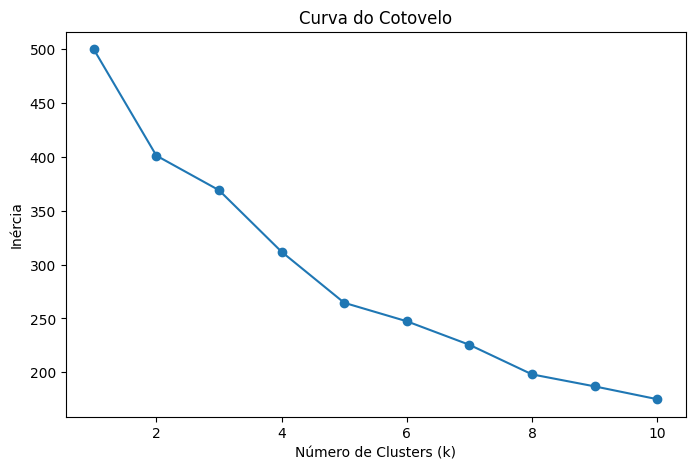

In [16]:
# Lista para armazenar os valores de inércia
inertia = []

# Testar valores de k
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotar a curva do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Curva do Cotovelo')
plt.show()


Melhor valor de k: 8, com escore de silhueta: 0.2038


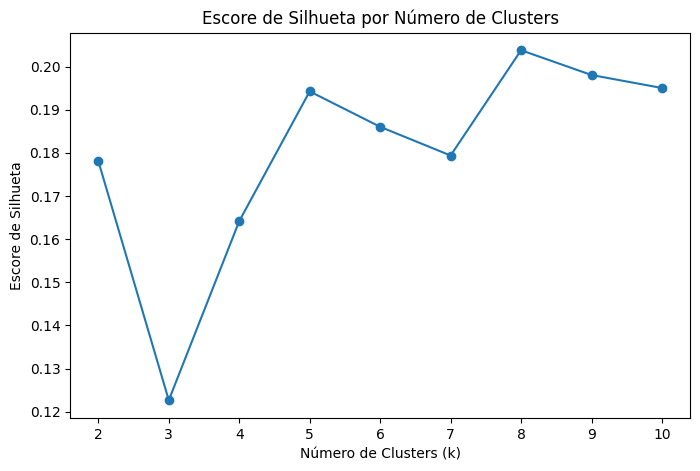

In [17]:
# Testar diferentes valores de k no intervalo ideal
silhouette_scores = []
best_k = 0
best_score = -1

for k in range(2, 11):  # Começa em 2 porque silhueta não é definida para k=1
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Calcular o escore de silhueta
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    if score > best_score:
        best_score = score
        best_k = k

# Exibir o melhor k e o escore correspondente
print(f'Melhor valor de k: {best_k}, com escore de silhueta: {best_score:.4f}')

# Plotar os scores de silhueta
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Escore de Silhueta')
plt.title('Escore de Silhueta por Número de Clusters')
plt.show()


In [18]:
# Treinar o modelo com o melhor k
final_kmeans = KMeans(n_clusters=best_k, random_state=42)
final_labels = final_kmeans.fit_predict(X_scaled)

# Adicionar os rótulos ao dataset original
data['Cluster'] = final_labels

# Exibir os primeiros resultados
data.head()


,nome,danceability,energy,loudness,tempo,valence,Cluster
0,Música_0,0.374540,0.031429,-21.478101,57.752258,0.103124,1
1,Música_1,0.950714,0.636410,-54.951602,129.703195,0.902553,5
2,Música_2,0.731994,0.314356,-50.302277,131.095268,0.505252,3
3,Música_3,0.598658,0.508571,-6.086749,145.614485,0.826457,6
4,Música_4,0.156019,0.907566,-23.614256,158.913700,0.320050,4


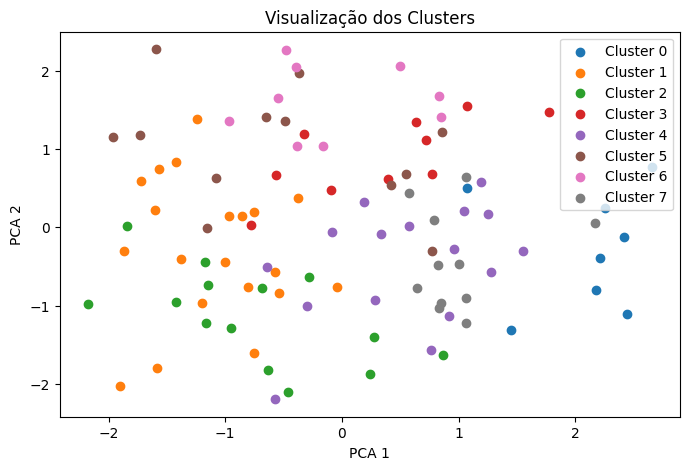

In [19]:
from sklearn.decomposition import PCA

# Reduzir para 2 dimensões
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotar os clusters
plt.figure(figsize=(8, 5))
for cluster in np.unique(final_labels):
    plt.scatter(X_pca[final_labels == cluster, 0],
                X_pca[final_labels == cluster, 1],
                label=f'Cluster {cluster}')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualização dos Clusters')
plt.legend()
plt.show()


Qual foi o número ideal de clusters e por quê?
Como o algoritmo performou para identificar grupos distintos de músicas?
Quais desafios ou observações você teve ao trabalhar com os dados?


O número ideal de clusters é 8 segundo o grafico de silhueta. O algoritmo KMeans, em combinação com o método da silhueta, teve como objetivo identificar grupos distintos de músicas com base nas features selecionadas (danceability, energy, loudness, tempo, valence). Dentre as dificuldades, a primeira foi a natureza subjetiva da música, a aleatoriedade também foi um ponto, para garantir reprodutibilidade utilizei random_state=42 no meu código.